#  AgriAI Assist — Crop Disease Detection & Yield Prediction

**Project:** AI-powered agricultural assistant for Indian farmers  
**Models:** ResNet50 (Disease Detection) + XGBoost (Yield Prediction)  
**Dataset 1:** PlantVillage — 54,306 leaf images, 38 disease classes  
**Dataset 2:** Indian Crop Yield CSV — 19,689 records across Indian states  

---
### ▶ How to run on Kaggle (recommended)
1. Open this notebook on Kaggle
2. Click **Settings** (right panel) → **Accelerator** → select **GPU P100** → Save
3. Click **+ Add Data** → search **`abdallahalidev/plantvillage-dataset`** → Add
4. Click **+ Add Data** → search your uploaded yield CSV dataset → Add
5. Click **Run All** — the notebook will auto-detect Kaggle paths

> **Yield CSV path:** Update `YIELD_CSV` in *Part 10* if your dataset slug differs.

---
### ▶ How to run on Google Colab
1. Runtime → Change runtime type → **T4 GPU**
2. Upload your `kaggle.json` when prompted in Part 2
3. Upload your `crop_yield.csv` when prompted in Part 10
4. Run All


---
## Part 1 — Environment Setup

In [1]:
# ── Detect environment (Colab / Kaggle / Local) ───────────────────────────────
import os, sys

IN_COLAB  = 'google.colab' in sys.modules
IN_KAGGLE = os.path.exists('/kaggle/input')
ENV       = 'colab' if IN_COLAB else ('kaggle' if IN_KAGGLE else 'local')

print(f'Running in: {ENV.upper()}')

Running in: KAGGLE


In [2]:
# ── Install dependencies ───────────────────────────────────────────────────────
# PyTorch + torchvision are pre-installed on both Colab and Kaggle.
# grad-cam and xgboost need to be added.
!pip install -q xgboost==2.0.3 grad-cam==1.5.0


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 297.1/297.1 MB 6.3 MB/s eta 0:00:00


In [3]:
# ── GPU check ─────────────────────────────────────────────────────────────────
import torch

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla P100-PCIE-16GB
Memory : 17.1 GB


In [4]:
# ── Global imports ────────────────────────────────────────────────────────────
import warnings, random, json, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from torchvision.utils import make_grid

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (r2_score, mean_absolute_error,
                              mean_squared_error, confusion_matrix,
                              ConfusionMatrixDisplay)
import xgboost as xgb

warnings.filterwarnings('ignore')

# ── Reproducibility ───────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if DEVICE.type == 'cuda':
    torch.cuda.manual_seed_all(SEED)

print('All imports successful.')

All imports successful.


---
## Part 2 — Download PlantVillage Dataset

In [5]:
# ── Dataset setup ─────────────────────────────────────────────────────────────
# On Kaggle: datasets are mounted automatically after adding them via + Add Data.
# On Colab:  upload your kaggle.json API token when prompted below.

if IN_COLAB:
    from google.colab import files
    print('Upload your kaggle.json file (Kaggle → Account → API → Create New Token):')
    files.upload()
    os.makedirs(os.path.expanduser('~/.kaggle'), exist_ok=True)
    !cp kaggle.json ~/.kaggle/
    !chmod 600 ~/.kaggle/kaggle.json
    print('✓ kaggle.json configured.')
elif IN_KAGGLE:
    print('✓ Running on Kaggle — datasets are auto-mounted at /kaggle/input/')
    print('  Make sure you have added:')
    print('  1. abdallahalidev/plantvillage-dataset')
    print('  2. Your crop yield CSV dataset')
    # List available input datasets
    import os
    for d in sorted(os.listdir('/kaggle/input')):
        print(f'     /kaggle/input/{d}')


✓ Running on Kaggle — datasets are auto-mounted at /kaggle/input/
  Make sure you have added:
  1. abdallahalidev/plantvillage-dataset
  2. Your crop yield CSV dataset
     /kaggle/input/datasets


In [6]:
# ── Set PlantVillage dataset path ─────────────────────────────────────────────

if IN_COLAB:
    !kaggle datasets download -d abdallahalidev/plantvillage-dataset
    !unzip -q plantvillage-dataset.zip -d plantvillage
    DATA_DIR = Path('plantvillage/plantvillage dataset/color')

elif IN_KAGGLE:
    DATA_DIR = Path('/kaggle/input/datasets/ribhzz/plant-data/plantvillage dataset/color')

else:
    DATA_DIR = Path('plantvillage/color')

print(f'DATA_DIR : {DATA_DIR}')
print(f'Exists   : {DATA_DIR.exists()}')
if DATA_DIR.exists():
    classes = sorted([d.name for d in DATA_DIR.iterdir() if d.is_dir()])
    print(f'Classes  : {len(classes)} found')
    print(f'First 5  : {classes[:5]}')
else:
    raise FileNotFoundError(f'DATA_DIR not found: {DATA_DIR}')


DATA_DIR : /kaggle/input/datasets/ribhzz/plant-data/plantvillage dataset/color
Exists   : True
Classes  : 38 found
First 5  : ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


---
## Part 3 — Disease Detection: Data Preprocessing

In [7]:
# ── Image transforms ──────────────────────────────────────────────────────────
IMG_SIZE   = 224
BATCH_SIZE = 32

# Training: aggressive augmentation to prevent overfitting
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.3),
    transforms.RandomRotation(degrees=30),
    transforms.ColorJitter(brightness=0.3, contrast=0.3,
                           saturation=0.3, hue=0.1),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.8, 1.0)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],  # ImageNet stats
                         std=[0.229, 0.224, 0.225]),
])

# Validation / test: only resize + normalize (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225]),
])

print('Transforms defined.')

Transforms defined.


In [8]:
# ── Load dataset and split 80/10/10 ───────────────────────────────────────────
full_dataset = datasets.ImageFolder(root=DATA_DIR,
                                    transform=train_transforms)

NUM_CLASSES  = len(full_dataset.classes)
CLASS_NAMES  = full_dataset.classes
total        = len(full_dataset)

train_size = int(0.80 * total)
val_size   = int(0.10 * total)
test_size  = total - train_size - val_size

train_ds, val_ds, test_ds = random_split(
    full_dataset, [train_size, val_size, test_size],
    generator=torch.Generator().manual_seed(SEED)
)

# Apply val transforms to val and test sets
val_ds.dataset.transform  = val_transforms
test_ds.dataset.transform = val_transforms

# DataLoaders
NUM_WORKERS = 2
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE,
                          shuffle=True,  num_workers=NUM_WORKERS,
                          pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=NUM_WORKERS,
                          pin_memory=True)

print(f'Total images  : {total:,}')
print(f'Classes       : {NUM_CLASSES}')
print(f'Train / Val / Test : {train_size:,} / {val_size:,} / {test_size:,}')

Total images  : 54,305
Classes       : 38
Train / Val / Test : 43,444 / 5,430 / 5,431


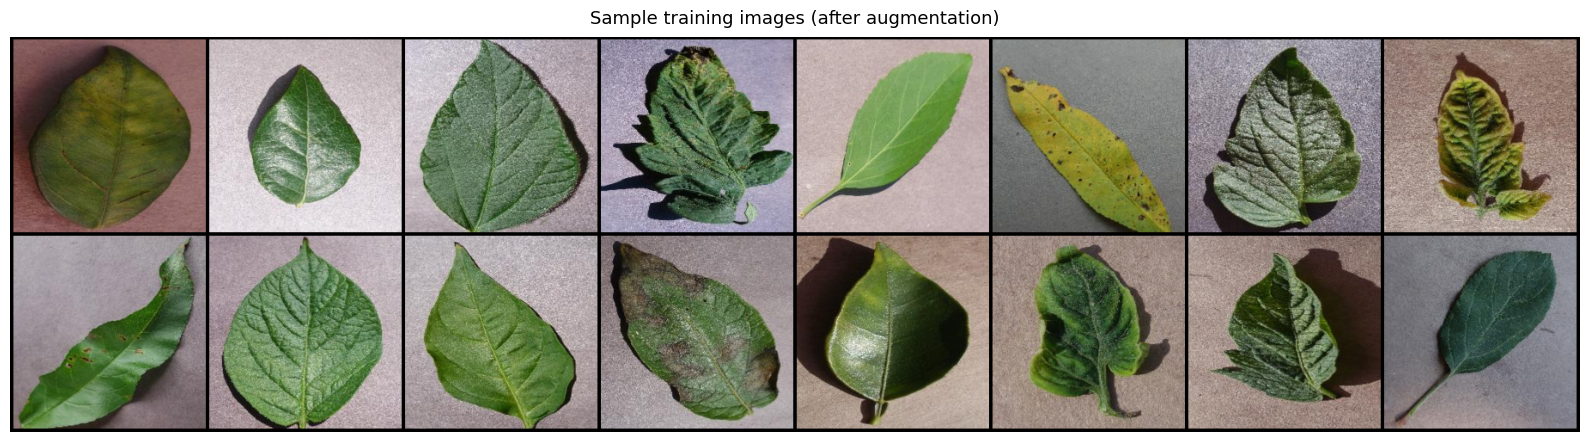

In [9]:
# ── Visualise a batch of training images ──────────────────────────────────────
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
    std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
    return torch.clamp(tensor * std + mean, 0, 1)

images, labels = next(iter(train_loader))
grid = make_grid(denormalize(images[:16]), nrow=8, padding=4)

fig, ax = plt.subplots(figsize=(16, 5))
ax.imshow(grid.permute(1, 2, 0))
ax.axis('off')
ax.set_title('Sample training images (after augmentation)',
             fontsize=13, pad=10)
plt.tight_layout()
plt.show()

---
## Part 4 — Disease Detection: CNN Model (ResNet50 Transfer Learning)

In [10]:
# ── Build ResNet50 with custom classification head ────────────────────────────
def build_model(num_classes: int, freeze_until: int = 45) -> nn.Module:
    """
    Load pretrained ResNet50, freeze early layers,
    replace FC head with a custom classifier.
    """
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)

    # Freeze all parameters first
    for param in model.parameters():
        param.requires_grad = False

    # Unfreeze the last few layers (layer4 + fc)
    layers_to_unfreeze = [model.layer4, model.fc]
    for layer in layers_to_unfreeze:
        for param in layer.parameters():
            param.requires_grad = True

    # Replace the final FC layer
    in_features = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )

    return model


model = build_model(NUM_CLASSES).to(DEVICE)

# Count trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_p   = sum(p.numel() for p in model.parameters())
print(f'Trainable params : {trainable:,} / {total_p:,}')

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 206MB/s]


Trainable params : 16,033,318 / 24,576,614


In [11]:
# ── Loss, optimizer, schedulers ───────────────────────────────────────────────
EPOCHS = 12
LR     = 1e-3

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LR, weight_decay=1e-4
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.3, patience=2
)

print(f'Optimizer : Adam (lr={LR})')
print(f'Scheduler : ReduceLROnPlateau (patience=2, factor=0.3)')
print(f'Epochs    : {EPOCHS}')

Optimizer : Adam (lr=0.001)
Scheduler : ReduceLROnPlateau (patience=2, factor=0.3)
Epochs    : 12


---
## Part 5 — Training Loop

In [12]:
# ── Heartbeat + Training loop ────────────────────────────────────────────────
# Kaggle kills idle kernels after ~20 min of no output.
# The heartbeat thread prints a '.' every 60 s so the kernel stays alive.
# It is automatically stopped when training finishes.

import threading, time, sys
from datetime import datetime

# ── Heartbeat ─────────────────────────────────────────────────────────────────
_hb_stop = threading.Event()

def _heartbeat(interval: int = 60):
    """Print a timestamp every `interval` seconds to keep Kaggle kernel alive."""
    while not _hb_stop.wait(interval):
        ts = datetime.now().strftime('%H:%M:%S')
        print(f'  [heartbeat {ts}] training in progress...', flush=True)

_hb_thread = threading.Thread(target=_heartbeat, daemon=True)
_hb_thread.start()
print('Heartbeat started (prints every 60 s to keep kernel alive).\n')

# ── History & hyperparams ─────────────────────────────────────────────────────
history = {'train_loss': [], 'train_acc': [],
           'val_loss':   [], 'val_acc':   []}

best_val_acc  = 0.0
patience_ctr  = 0
EARLY_STOP    = 4
SAVE_DIR      = Path('/kaggle/working') if IN_KAGGLE else Path('.')
CKPT_BEST     = SAVE_DIR / 'best_disease_model.pt'
CKPT_EPOCH    = SAVE_DIR / 'last_epoch_model.pt'   # overwritten each epoch

# ── Mini-batch progress bar ───────────────────────────────────────────────────
def run_epoch(loader, train=True):
    model.train() if train else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    n_batches = len(loader)
    phase = 'train' if train else 'val  '

    ctx = torch.enable_grad() if train else torch.no_grad()
    with ctx:
        for batch_idx, (images, labels) in enumerate(loader, 1):
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            if train:
                optimizer.zero_grad()
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if train:
                loss.backward()
                optimizer.step()

            total_loss += loss.item() * images.size(0)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += images.size(0)

            # Print progress every 50 batches so output stays live
            if batch_idx % 50 == 0 or batch_idx == n_batches:
                pct  = batch_idx / n_batches
                bar  = ('█' * int(pct * 20)).ljust(20)
                acc  = correct / total
                loss_avg = total_loss / total
                print(f'  [{phase}] {bar} {pct:5.1%}'
                      f'  loss={loss_avg:.4f}  acc={acc:.2%}'
                      f'  ({batch_idx}/{n_batches})',
                      end='\r', flush=True)

    print()  # newline after progress bar
    return total_loss / total, correct / total


# ── Training loop ─────────────────────────────────────────────────────────────
print(f"{'Epoch':>5}  {'TrainLoss':>9}  {'TrainAcc':>8}  "
      f"{'ValLoss':>8}  {'ValAcc':>7}  {'LR':>8}  {'Time':>6}  {'Status'}")
print('─' * 80)

train_start = time.time()

try:
    for epoch in range(1, EPOCHS + 1):
        t0 = time.time()
        print(f'\nEpoch {epoch}/{EPOCHS}  ──────────────────────────────────────────')

        tr_loss, tr_acc = run_epoch(train_loader, train=True)
        vl_loss, vl_acc = run_epoch(val_loader,   train=False)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        cur_lr    = optimizer.param_groups[0]['lr']
        epoch_sec = time.time() - t0
        is_best   = vl_acc > best_val_acc
        status    = '★ BEST' if is_best else ''

        print(f"  {epoch:>5}  {tr_loss:>9.4f}  {tr_acc:>8.2%}  "
              f"{vl_loss:>8.4f}  {vl_acc:>7.2%}  {cur_lr:>8.2e}  "
              f"{epoch_sec:>5.0f}s  {status}")

        # ── Checkpoint: always save last epoch ────────────────────────────────
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state':  optimizer.state_dict(),
            'val_acc':          vl_acc,
            'history':          history,
        }, CKPT_EPOCH)

        # ── Checkpoint: save best ─────────────────────────────────────────────
        if is_best:
            best_val_acc = vl_acc
            torch.save(model.state_dict(), CKPT_BEST)
            patience_ctr = 0
            print(f'  → Saved best model  (val_acc={best_val_acc:.2%})')
        else:
            patience_ctr += 1
            print(f'  → No improvement ({patience_ctr}/{EARLY_STOP})')
            if patience_ctr >= EARLY_STOP:
                print(f'\n  Early stopping at epoch {epoch}.')
                break

except KeyboardInterrupt:
    print('\nTraining interrupted — checkpoints saved.')

finally:
    # Always stop heartbeat
    _hb_stop.set()
    _hb_thread.join(timeout=2)
    total_sec = time.time() - train_start
    print(f'\nHeartbeat stopped.')
    print(f'Total training time : {total_sec/60:.1f} min')
    print(f'Best val accuracy   : {best_val_acc:.2%}')
    print(f'Best model saved to : {CKPT_BEST}')
    print(f'Last epoch saved to : {CKPT_EPOCH}')


Heartbeat started (prints every 60 s to keep kernel alive).

Epoch  TrainLoss  TrainAcc   ValLoss   ValAcc        LR    Time  Status
────────────────────────────────────────────────────────────────────────────────

Epoch 1/12  ──────────────────────────────────────────
  [heartbeat 12:42:54] training in progress...
  [heartbeat 12:43:54] training in progress...
  [train] ████████████████████ 100.0%  loss=0.8945  acc=94.67%  (1358/1358)
  [val  ] ████████████████████ 100.0%  loss=0.7447  acc=98.91%  (170/170)
      1     0.8945    94.67%    0.7447   98.91%  1.00e-03    159s  ★ BEST
  → Saved best model  (val_acc=98.91%)

Epoch 2/12  ──────────────────────────────────────────
  [heartbeat 12:44:54] training in progress...
  [heartbeat 12:45:54] training in progress...
  [train] ████████████████████ 100.0%  loss=0.7673  acc=98.59%  (1358/1358)
  [val  ] ████████████████████ 100.0%  loss=0.7351  acc=98.88%  (170/170)
      2     0.7673    98.59%    0.7351   98.88%  1.00e-03    114s  
  → N

---
## Part 6 — Model Evaluation & Plots

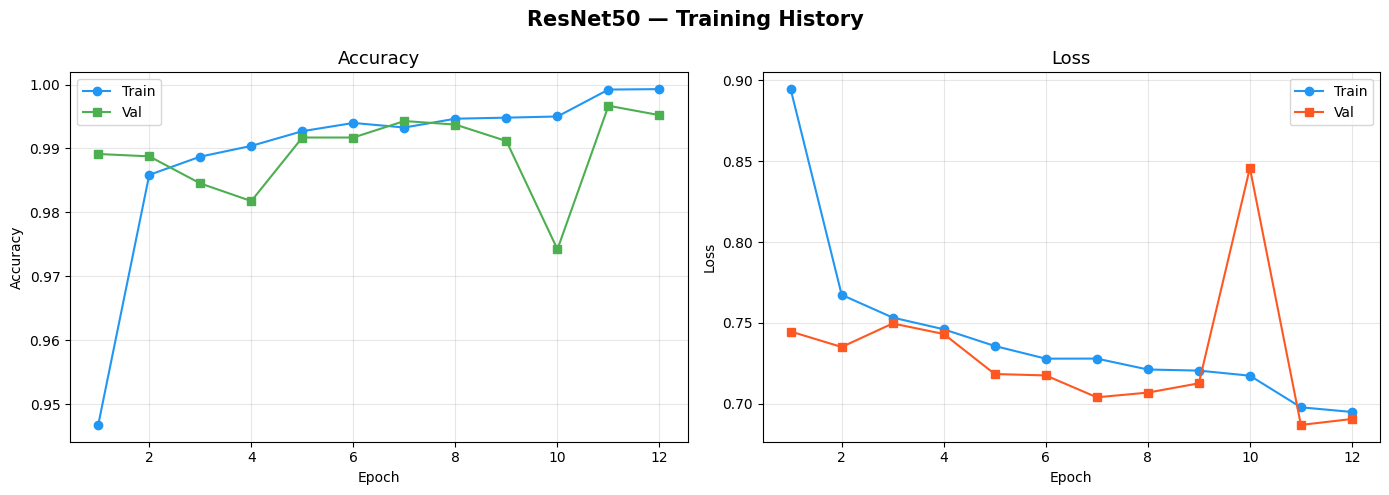

In [13]:
# ── Training curves ───────────────────────────────────────────────────────────
epochs_ran = range(1, len(history['train_acc']) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs_ran, history['train_acc'], 'o-', label='Train', color='#2196F3')
ax1.plot(epochs_ran, history['val_acc'],   's-', label='Val',   color='#4CAF50')
ax1.set_title('Accuracy', fontsize=13)
ax1.set_xlabel('Epoch'); ax1.set_ylabel('Accuracy')
ax1.legend(); ax1.grid(alpha=0.3)

ax2.plot(epochs_ran, history['train_loss'], 'o-', label='Train', color='#2196F3')
ax2.plot(epochs_ran, history['val_loss'],   's-', label='Val',   color='#FF5722')
ax2.set_title('Loss', fontsize=13)
ax2.set_xlabel('Epoch'); ax2.set_ylabel('Loss')
ax2.legend(); ax2.grid(alpha=0.3)

plt.suptitle('ResNet50 — Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

In [14]:
# ── Test set evaluation ───────────────────────────────────────────────────────
# Load best checkpoint
model.load_state_dict(torch.load('best_disease_model.pt', map_location=DEVICE))
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(DEVICE)
        preds  = model(images).argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f'Test Accuracy : {test_acc:.2%}')

Test Accuracy : 99.59%


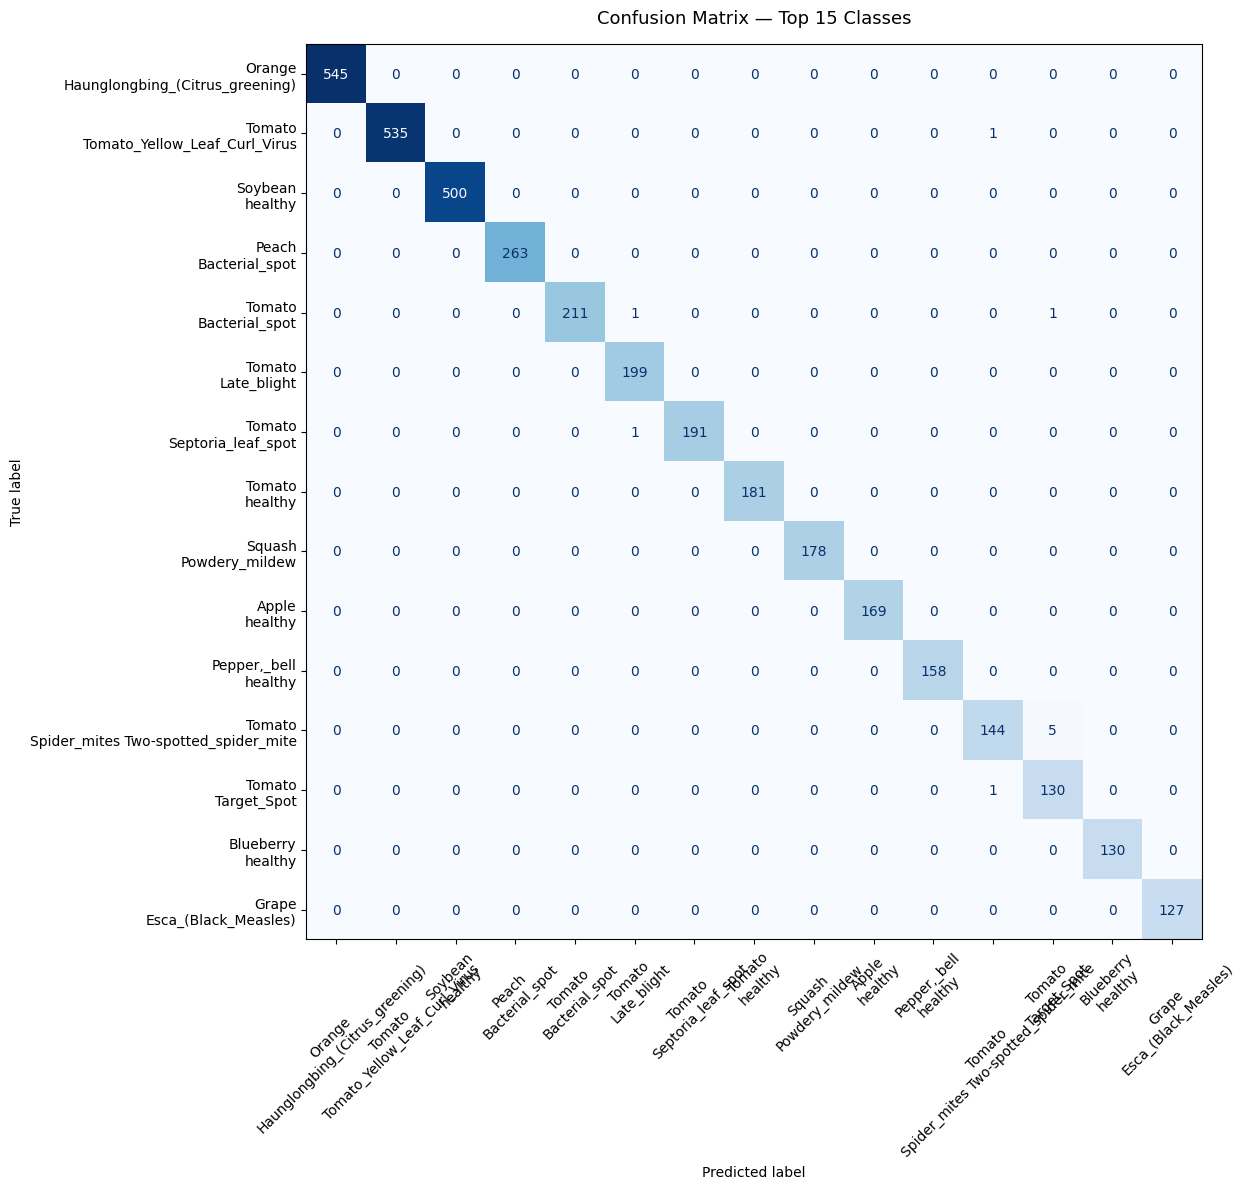

In [15]:
# ── Confusion matrix (top 15 most common classes for readability) ─────────────
from collections import Counter

top_idx = [i for i, _ in Counter(all_labels.tolist()).most_common(15)]
mask    = np.isin(all_labels, top_idx)
sub_labels = all_labels[mask]
sub_preds  = all_preds[mask]
sub_names  = [CLASS_NAMES[i].replace('___', '\n') for i in top_idx]

cm = confusion_matrix(sub_labels, sub_preds, labels=top_idx)

fig, ax = plt.subplots(figsize=(14, 12))
disp = ConfusionMatrixDisplay(cm, display_labels=sub_names)
disp.plot(ax=ax, colorbar=False, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Top 15 Classes', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

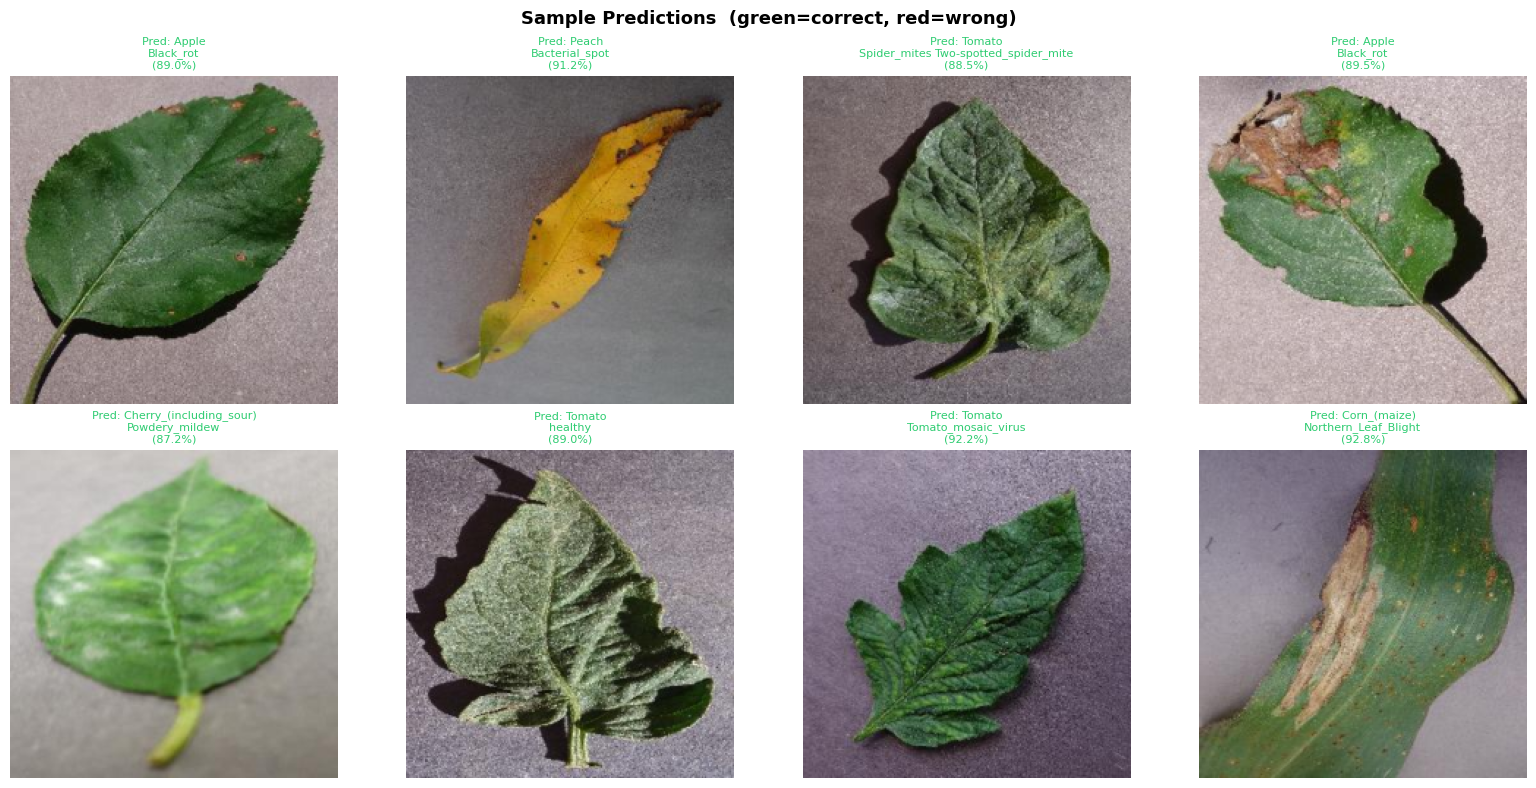

In [16]:
# ── Sample predictions with confidence ───────────────────────────────────────
model.eval()
images, labels = next(iter(test_loader))
images_gpu = images[:8].to(DEVICE)

with torch.no_grad():
    logits = model(images_gpu)
    probs  = torch.softmax(logits, dim=1)
    confs, preds = probs.max(1)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for i, ax in enumerate(axes.flat):
    img = denormalize(images[i]).permute(1, 2, 0).numpy()
    ax.imshow(img)
    ax.axis('off')
    pred_name  = CLASS_NAMES[preds[i]].replace('___', '\n')
    true_name  = CLASS_NAMES[labels[i]].replace('___', '\n')
    correct    = preds[i].item() == labels[i].item()
    color      = '#2ecc71' if correct else '#e74c3c'
    ax.set_title(f'Pred: {pred_name}\n({confs[i]:.1%})',
                 fontsize=8, color=color)

plt.suptitle('Sample Predictions  (green=correct, red=wrong)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## Part 7 — Disease → Remedy Mapping

In [17]:
# ── Disease → Treatment dictionary ───────────────────────────────────────────
REMEDY_MAP = {
    # Tomato
    'Tomato___Bacterial_spot': [
        'Apply copper-based bactericide every 7–10 days.',
        'Remove and destroy infected plant debris.',
        'Avoid overhead irrigation; use drip systems.',
        'Use certified disease-free seeds.'
    ],
    'Tomato___Early_blight': [
        'Apply Mancozeb or Chlorothalonil fungicide.',
        'Remove lower infected leaves immediately.',
        'Mulch soil to prevent spore splash-up.',
        'Rotate crops — avoid planting tomato in same spot.'
    ],
    'Tomato___Late_blight': [
        'Apply Metalaxyl or copper fungicide immediately.',
        'Remove and burn infected leaves — do not compost.',
        'Avoid overhead watering.',
        'Act within 48 hours — spreads rapidly in humid weather.'
    ],
    'Tomato___Leaf_Mold': [
        'Improve greenhouse ventilation.',
        'Apply Chlorothalonil or Mancozeb fungicide.',
        'Reduce leaf wetness — water at base only.',
        'Remove severely infected leaves.'
    ],
    'Tomato___Septoria_leaf_spot': [
        'Apply Mancozeb or Copper fungicide.',
        'Remove infected lower leaves.',
        'Practice 2-year crop rotation.',
        'Stake plants to improve air circulation.'
    ],
    'Tomato___Spider_mites Two-spotted_spider_mite': [
        'Apply Neem oil or insecticidal soap spray.',
        'Introduce predatory mites (Phytoseiulus persimilis).',
        'Increase humidity — mites thrive in dry conditions.',
        'Avoid water stress — keep plants well irrigated.'
    ],
    'Tomato___Target_Spot': [
        'Apply Azoxystrobin or Chlorothalonil fungicide.',
        'Ensure proper plant spacing for air flow.',
        'Avoid overhead irrigation.',
        'Remove and dispose of infected material.'
    ],
    'Tomato___Tomato_Yellow_Leaf_Curl_Virus': [
        'Control whitefly population (primary vector).',
        'Use reflective silver mulch to repel whiteflies.',
        'Remove and destroy infected plants immediately.',
        'Plant virus-resistant tomato varieties.'
    ],
    'Tomato___Tomato_mosaic_virus': [
        'No cure — remove infected plants immediately.',
        'Sanitize all tools with 10% bleach solution.',
        'Wash hands before handling plants.',
        'Plant TMV-resistant seed varieties next season.'
    ],
    'Tomato___healthy': [
        'Plant looks healthy! Continue current care routine.',
        'Monitor weekly for early signs of disease.',
        'Maintain consistent watering and fertilization.'
    ],
    # Potato
    'Potato___Early_Blight': [
        'Apply Mancozeb fungicide at first sign.',
        'Remove infected leaves and dispose safely.',
        'Ensure adequate potassium fertilization.',
        'Avoid water stress during tuber development.'
    ],
    'Potato___Late_Blight': [
        'Apply Metalaxyl + Mancozeb fungicide immediately.',
        'Destroy infected tubers — do not leave in field.',
        'Hilling helps protect tubers from spore infection.',
        'URGENT: spreads very fast — treat within 24 hours.'
    ],
    'Potato___healthy': [
        'Plant looks healthy! Maintain current practices.',
        'Ensure proper hilling to protect developing tubers.'
    ],
    # Corn
    'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot': [
        'Apply Azoxystrobin or Propiconazole fungicide.',
        'Plant resistant hybrids in next season.',
        'Improve air circulation through proper spacing.',
        'Till crop residue to reduce overwintering spores.'
    ],
    'Corn_(maize)___Common_rust_': [
        'Apply Mancozeb or Azoxystrobin fungicide.',
        'Plant rust-resistant corn varieties.',
        'Early planting helps avoid peak rust season.',
        'Monitor closely — spreads quickly in cool, moist weather.'
    ],
    'Corn_(maize)___Northern_Leaf_Blight': [
        'Apply Propiconazole fungicide at early tassel stage.',
        'Use resistant hybrids for future planting.',
        'Rotate with non-host crops (soybean, wheat).',
        'Destroy infected crop residue after harvest.'
    ],
    'Corn_(maize)___healthy': [
        'Plant looks healthy! Maintain current practices.',
        'Ensure adequate nitrogen at key growth stages.'
    ],
    # Apple
    'Apple___Apple_scab': [
        'Apply Captan or Myclobutanil fungicide at bud break.',
        'Rake and destroy fallen leaves in autumn.',
        'Prune for open canopy to improve air circulation.',
        'Apply protective sprays every 7–14 days.'
    ],
    'Apple___Black_rot': [
        'Prune out all dead or diseased wood immediately.',
        'Apply Captan or Thiophanate-methyl fungicide.',
        'Remove mummified fruit from trees and ground.',
        'Avoid wounding trees during pruning.'
    ],
    'Apple___Cedar_apple_rust': [
        'Apply Myclobutanil or Mancozeb at pink bud stage.',
        'Remove nearby eastern red cedar trees if possible.',
        'Plant rust-resistant apple varieties.',
        'Repeat fungicide applications every 7–10 days.'
    ],
    'Apple___healthy': [
        'Plant looks healthy! Continue current orchard management.',
        'Monitor for pests and diseases weekly.'
    ],
    # Grape
    'Grape___Black_rot': [
        'Apply Mancozeb or Myclobutanil fungicide.',
        'Remove all mummified berries from vine and ground.',
        'Prune for good canopy air circulation.',
        'Begin sprays at bud swell and continue every 10–14 days.'
    ],
    'Grape___Esca_(Black_Measles)': [
        'No effective chemical cure — manage through pruning.',
        'Remove and burn severely infected vines.',
        'Avoid pruning during wet weather.',
        'Apply wound sealant after every pruning cut.'
    ],
    'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)': [
        'Apply Mancozeb or Copper-based fungicide.',
        'Improve air circulation by canopy management.',
        'Avoid excessive nitrogen fertilization.',
        'Remove infected leaves and destroy.'
    ],
    'Grape___healthy': [
        'Vine looks healthy! Maintain current practices.',
        'Monitor for powdery mildew in humid conditions.'
    ],
    # Pepper
    'Pepper,_bell___Bacterial_spot': [
        'Apply copper-based bactericide every 7 days.',
        'Use disease-free certified transplants.',
        'Avoid overhead irrigation.',
        'Rotate crops — do not grow peppers in same field for 2 years.'
    ],
    'Pepper,_bell___healthy': [
        'Plant looks healthy! Continue current care.',
        'Ensure consistent moisture for best fruit set.'
    ],
    # Strawberry
    'Strawberry___Leaf_scorch': [
        'Apply Myclobutanil or Captan fungicide.',
        'Remove and destroy infected leaves.',
        'Avoid overhead watering.',
        'Improve drainage and air circulation.'
    ],
    'Strawberry___healthy': [
        'Plant looks healthy! Maintain runner management.',
        'Monitor for spider mites in hot, dry conditions.'
    ],
    # Peach
    'Peach___Bacterial_spot': [
        'Apply copper-based bactericide in early spring.',
        'Prune for open center canopy structure.',
        'Avoid excessive nitrogen — promotes susceptible growth.',
        'Plant resistant varieties where possible.'
    ],
    'Peach___healthy': [
        'Tree looks healthy! Maintain dormant sprays.',
        'Monitor for peach leaf curl in spring.'
    ],
    # Squash
    'Squash___Powdery_mildew': [
        'Apply potassium bicarbonate or Neem oil spray.',
        'Improve spacing — powdery mildew loves poor air flow.',
        'Avoid wetting foliage — water at base only.',
        'Remove heavily infected leaves.'
    ],
    # Cherry
    'Cherry_(including_sour)___Powdery_mildew': [
        'Apply Sulfur-based or Myclobutanil fungicide.',
        'Prune for open canopy to allow light penetration.',
        'Avoid excessive nitrogen fertilization.',
        'Remove and destroy infected shoots.'
    ],
    'Cherry_(including_sour)___healthy': [
        'Tree looks healthy! Maintain regular monitoring.',
        'Apply dormant oil spray before bud break.'
    ],
    # Soybean
    'Soybean___healthy': [
        'Plant looks healthy! Continue current practices.',
        'Monitor for sudden death syndrome after heavy rains.'
    ],
    # Raspberry
    'Raspberry___healthy': [
        'Plant looks healthy! Maintain proper cane management.',
        'Remove old floricanes after harvest.'
    ],
    # Blueberry
    'Blueberry___healthy': [
        'Plant looks healthy! Maintain acidic soil pH (4.5–5.5).',
        'Monitor for mummy berry disease during bloom.'
    ],
    # Orange
    'Orange___Haunglongbing_(Citrus_greening)': [
        'NO CURE — remove and destroy infected trees immediately.',
        'Control Asian citrus psyllid (disease vector).',
        'Quarantine the area — report to local agriculture office.',
        'Do not move plant material out of the infected zone.'
    ],
}

# Default for any class not explicitly mapped
DEFAULT_REMEDY = [
    'Consult your local agricultural extension office.',
    'Remove and isolate infected plant material.',
    'Apply a broad-spectrum fungicide as a precaution.',
    'Monitor neighbouring plants for spread.'
]

print(f'Remedy map loaded: {len(REMEDY_MAP)} diseases covered.')

Remedy map loaded: 38 diseases covered.


---
## Part 8 — Grad-CAM Explainability

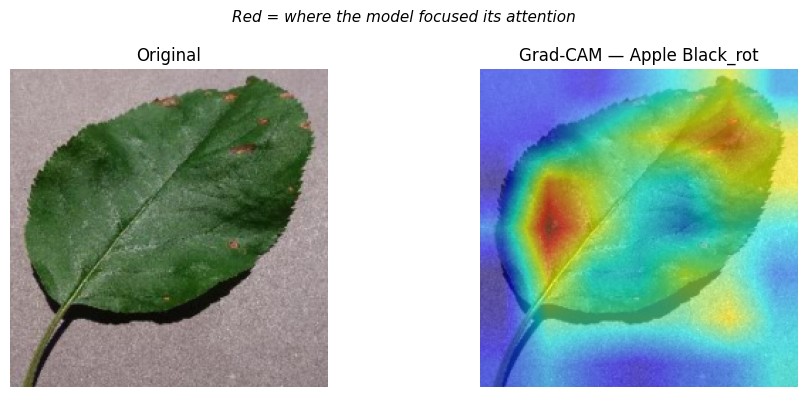

In [18]:
# ── Grad-CAM heatmap on a sample image ───────────────────────────────────────
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

# Target the last conv block of ResNet50
target_layers = [model.layer4[-1]]

# Pick one test image
sample_img, sample_label = test_ds[0]
input_tensor = sample_img.unsqueeze(0).to(DEVICE)

with GradCAM(model=model, target_layers=target_layers) as cam:
    targets   = [ClassifierOutputTarget(sample_label)]
    grayscale = cam(input_tensor=input_tensor, targets=targets)[0]

# Denormalize for display
rgb_img = denormalize(sample_img).permute(1, 2, 0).numpy()
cam_img = show_cam_on_image(rgb_img, grayscale, use_rgb=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4))
ax1.imshow(rgb_img);  ax1.axis('off'); ax1.set_title('Original', fontsize=12)
ax2.imshow(cam_img);  ax2.axis('off')
ax2.set_title(f'Grad-CAM — {CLASS_NAMES[sample_label].replace("___", " ")}',
              fontsize=12)
plt.suptitle('Red = where the model focused its attention',
             fontsize=11, style='italic')
plt.tight_layout()
plt.show()

---
## Part 9 — Save Disease Model

In [19]:
# ── Save model weights + class names ─────────────────────────────────────────
# On Kaggle, only /kaggle/working/ is writable.
SAVE_DIR = Path('/kaggle/working') if IN_KAGGLE else Path('.')
MODEL_PATH = SAVE_DIR / 'disease_model.pt'

torch.save({
    'model_state_dict': model.state_dict(),
    'class_names':      CLASS_NAMES,
    'num_classes':      NUM_CLASSES,
    'test_accuracy':    test_acc,
}, MODEL_PATH)

print(f'✓ Model saved: {MODEL_PATH}')
print(f'  Test accuracy: {test_acc:.2%}')

# On Colab: trigger browser download
if IN_COLAB:
    from google.colab import files
    files.download(str(MODEL_PATH))
    print('Download started — save to your Project/models/ folder.')

# On Kaggle: file is in Output tab → Save Version → Download
elif IN_KAGGLE:
    print('Find the file in the Output panel → Save Version → download disease_model.pt')


✓ Model saved: /kaggle/working/disease_model.pt
  Test accuracy: 99.59%
Find the file in the Output panel → Save Version → download disease_model.pt


In [20]:
# ── predict_disease() — reusable inference function ───────────────────────────
from PIL import Image

def predict_disease(image_path: str, top_k: int = 3) -> dict:
    """
    Predict crop disease from a leaf image.

    Args:
        image_path: Path to the leaf image file.
        top_k:      Number of top predictions to return.

    Returns:
        dict with keys: disease, confidence, remedies, top_k_predictions
    """
    model.eval()
    img = Image.open(image_path).convert('RGB')
    tensor = val_transforms(img).unsqueeze(0).to(DEVICE)

    with torch.no_grad():
        logits = model(tensor)
        probs  = torch.softmax(logits, dim=1)[0]

    top_probs, top_idxs = probs.topk(top_k)
    top_predictions = [
        {'disease': CLASS_NAMES[i], 'confidence': f'{p:.2%}'}
        for p, i in zip(top_probs.cpu(), top_idxs.cpu())
    ]

    best_class = CLASS_NAMES[top_idxs[0]]
    remedies   = REMEDY_MAP.get(best_class, DEFAULT_REMEDY)

    return {
        'disease':          best_class,
        'confidence':       f'{top_probs[0]:.2%}',
        'remedies':         remedies,
        'top_k_predictions': top_predictions
    }


# ── Quick test ────────────────────────────────────────────────────────────────
# Grab a random test image to verify the function works
import random as rnd
sample_path = rnd.choice(list(DATA_DIR.rglob('*.jpg')))
result = predict_disease(str(sample_path))

print('--- Disease Prediction Result ---')
print(f"Disease    : {result['disease']}")
print(f"Confidence : {result['confidence']}")
print('Remedies   :')
for i, r in enumerate(result['remedies'], 1):
    print(f'  {i}. {r}')
print('\nTop-3 Predictions:')
for p in result['top_k_predictions']:
    print(f"  {p['disease']:40s} {p['confidence']}")

--- Disease Prediction Result ---
Disease    : Corn_(maize)___healthy
Confidence : 91.44%
Remedies   :
  1. Plant looks healthy! Maintain current practices.
  2. Ensure adequate nitrogen at key growth stages.

Top-3 Predictions:
  Corn_(maize)___healthy                   91.44%
  Corn_(maize)___Northern_Leaf_Blight      0.35%
  Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot 0.31%


---
## Part 10 — Yield Prediction: Data Preprocessing

In [21]:
if IN_COLAB:
    from google.colab import files
    print('Upload your crop_yield.csv file:')
    uploaded = files.upload()
    YIELD_CSV = list(uploaded.keys())[0]

elif IN_KAGGLE:
    YIELD_CSV = '/kaggle/input/datasets/ribhzz/crop-data/crop_yield.csv'
    print(f'Found CSV: {YIELD_CSV}')

else:
    YIELD_CSV = 'crop_yield.csv'

df = pd.read_csv(YIELD_CSV)
print(f'Shape   : {df.shape}')
print(f'Columns : {list(df.columns)}')
df.head()

Found CSV: /kaggle/input/datasets/ribhzz/crop-data/crop_yield.csv
Shape   : (19689, 10)
Columns : ['Crop', 'Crop_Year', 'Season', 'State', 'Area', 'Production', 'Annual_Rainfall', 'Fertilizer', 'Pesticide', 'Yield']


,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909


In [22]:
df.head(100)

,Crop,Crop_Year,Season,State,Area,Production,Annual_Rainfall,Fertilizer,Pesticide,Yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,2051.4,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,2051.4,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,2051.4,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,2051.4,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,2051.4,165500.63,539.09,0.420909
...,...,...,...,...,...,...,...,...,...,...
95,Cotton(lint),1997,Kharif,West Bengal,26000.0,52000,1852.9,2474420.00,8060.00,2.000000
96,Dry chillies,1997,Whole Year,West Bengal,64034.0,55569,1852.9,6094115.78,19850.54,0.942778
97,Gram,1997,Rabi,West Bengal,25485.0,16994,1852.9,2425407.45,7900.35,0.597500
98,Groundnut,1997,Whole Year,West Bengal,29615.0,38672,1852.9,2818459.55,9180.65,1.130000


In [23]:
df['Crop'].value_counts()

Crop
Rice                     1197
Maize                     975
Moong(Green Gram)         740
Urad                      733
Groundnut                 725
Sesamum                   685
Potato                    628
Sugarcane                 605
Wheat                     545
Rapeseed &Mustard         528
Bajra                     524
Jowar                     513
Arhar/Tur                 508
Ragi                      498
Gram                      490
Small millets             485
Cotton(lint)              476
Onion                     454
Sunflower                 441
Dry chillies              419
Other Kharif pulses       382
Horse-gram                371
Peas & beans (Pulses)     369
Tobacco                   364
Other  Rabi pulses        355
Soyabean                  349
Turmeric                  337
Masoor                    324
Ginger                    323
Linseed                   308
Castor seed               300
Barley                    297
Sweet potato              273
Garli

Dataset info:
  Rows          : 19,689
  Nulls         : 0
  Crops         : 55
  States        : 30
  Year range    : 1997 – 2020
  Yield range   : 0.00 – 21105.00 t/ha


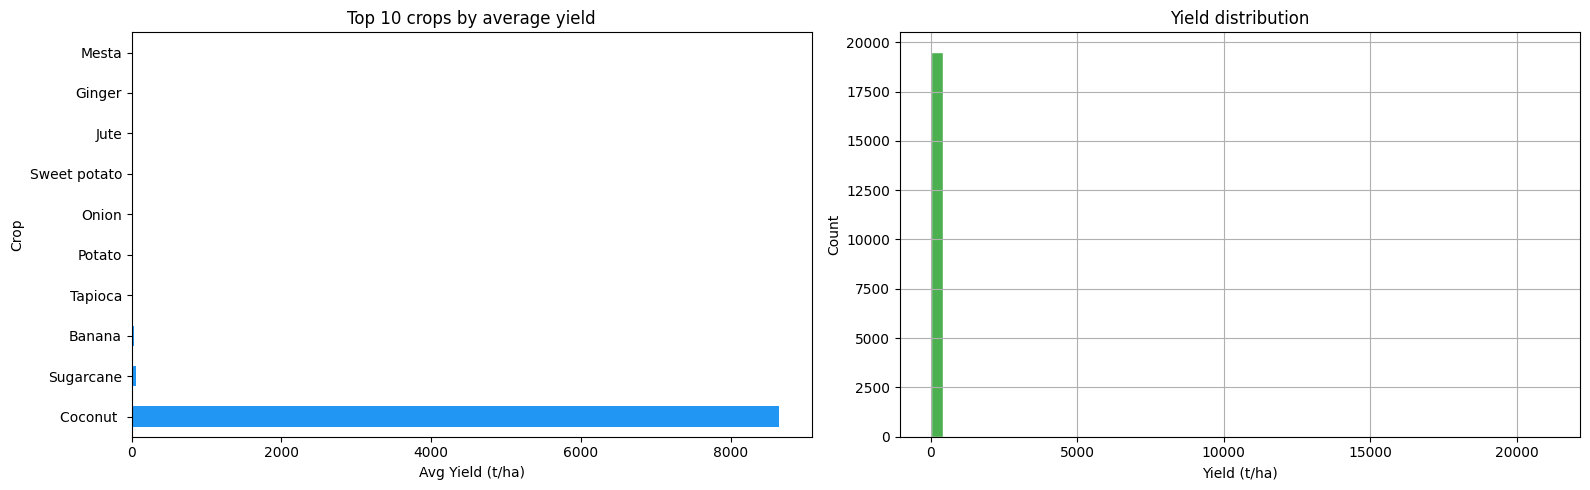

In [24]:
# ── EDA ───────────────────────────────────────────────────────────────────────
print('Dataset info:')
print(f'  Rows          : {len(df):,}')
print(f'  Nulls         : {df.isnull().sum().sum()}')
print(f'  Crops         : {df["Crop"].nunique()}')
print(f'  States        : {df["State"].nunique()}')
print(f'  Year range    : {df["Crop_Year"].min()} – {df["Crop_Year"].max()}')
print(f'  Yield range   : {df["Yield"].min():.2f} – {df["Yield"].max():.2f} t/ha')

# Top 10 crops by average yield
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

top_crops = df.groupby('Crop')['Yield'].mean().nlargest(10)
top_crops.plot(kind='barh', ax=axes[0], color='#2196F3')
axes[0].set_title('Top 10 crops by average yield', fontsize=12)
axes[0].set_xlabel('Avg Yield (t/ha)')

df['Yield'].hist(bins=50, ax=axes[1], color='#4CAF50', edgecolor='white')
axes[1].set_title('Yield distribution', fontsize=12)
axes[1].set_xlabel('Yield (t/ha)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [25]:
# ── Preprocessing ─────────────────────────────────────────────────────────────
df_clean = df.copy()

# Strip whitespace from string columns
for col in ['Crop', 'Season', 'State']:
    df_clean[col] = df_clean[col].str.strip()

# Handle missing values
df_clean.dropna(inplace=True)

# Remove extreme outliers (yield > 99th percentile)
q99 = df_clean['Yield'].quantile(0.99)
df_clean = df_clean[df_clean['Yield'] <= q99]
print(f'Rows after outlier removal: {len(df_clean):,}')

# ── Label encode categoricals ─────────────────────────────────────────────────
encoders = {}
for col in ['Crop', 'Season', 'State']:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])
    encoders[col] = le
    print(f'  {col}: {len(le.classes_)} unique values')

# ── Features and target ───────────────────────────────────────────────────────
FEATURES = ['Crop', 'Crop_Year', 'Season', 'State',
            'Area', 'Annual_Rainfall', 'Fertilizer', 'Pesticide']
TARGET   = 'Yield'

X = df_clean[FEATURES].values
y = df_clean[TARGET].values

# ── Feature scaling ───────────────────────────────────────────────────────────
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ── Train / test split ────────────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=SEED
)

print(f'\nTrain: {X_train.shape[0]:,}  |  Test: {X_test.shape[0]:,}')

Rows after outlier removal: 19,492
  Crop: 55 unique values
  Season: 6 unique values
  State: 30 unique values

Train: 15,593  |  Test: 3,899


---
## Part 11 — Yield Prediction: XGBoost Training

In [26]:
# ── XGBoost training with heartbeat ──────────────────────────────────────────
# XGBoost training is silent for long stretches — heartbeat prevents
# Kaggle from killing the kernel.

import threading, time
from datetime import datetime

# ── Heartbeat ─────────────────────────────────────────────────────────────────
_xgb_stop = threading.Event()

def _xgb_heartbeat(interval: int = 45):
    while not _xgb_stop.wait(interval):
        ts = datetime.now().strftime('%H:%M:%S')
        print(f'  [heartbeat {ts}] XGBoost training in progress...', flush=True)

_xgb_thread = threading.Thread(target=_xgb_heartbeat, daemon=True)
_xgb_thread.start()
print('XGBoost heartbeat started (prints every 45 s).\n')

# ── Custom verbose callback for round-by-round output ─────────────────────────
class PrintCallback(xgb.callback.TrainingCallback):
    """Print RMSE every 25 rounds with a timestamp."""
    def after_iteration(self, model, epoch, evals_log):
        if (epoch + 1) % 25 == 0 or epoch == 0:
            ts  = datetime.now().strftime('%H:%M:%S')
            val = evals_log.get('validation_0', {}).get('rmse', [None])
            trn = evals_log.get('training',     {}).get('rmse', [None])
            v   = f'{val[-1]:.4f}' if val[-1] is not None else 'N/A'
            t   = f'{trn[-1]:.4f}' if trn[-1] is not None else 'N/A'
            print(f'  [{ts}] Round {epoch+1:>4}  train_rmse={t}  val_rmse={v}',
                  flush=True)
        return False  # False = continue training

# ── Model definition ──────────────────────────────────────────────────────────
yield_model = xgb.XGBRegressor(
    n_estimators     = 300,
    learning_rate    = 0.05,
    max_depth        = 6,
    subsample        = 0.8,
    colsample_bytree = 0.8,
    reg_alpha        = 0.1,
    reg_lambda       = 1.0,
    random_state     = SEED,
    n_jobs           = -1,
    verbosity        = 0,
    callbacks        = [PrintCallback()],
)

# ── Train ─────────────────────────────────────────────────────────────────────
t0 = time.time()
try:
    yield_model.fit(
        X_train, y_train,
        eval_set        = [(X_train, y_train), (X_test, y_test)],
        eval_metric     = 'rmse',
        verbose         = False,
    )
except KeyboardInterrupt:
    print('\nXGBoost training interrupted.')
finally:
    _xgb_stop.set()
    _xgb_thread.join(timeout=2)
    elapsed = time.time() - t0
    print(f'\nHeartbeat stopped.')
    print(f'XGBoost training time: {elapsed:.1f} s')
    print('Training complete.')


XGBoost heartbeat started (prints every 45 s).

  [13:06:37] Round    1  train_rmse=N/A  val_rmse=10.2287
  [13:06:37] Round   25  train_rmse=N/A  val_rmse=5.1433
  [13:06:37] Round   50  train_rmse=N/A  val_rmse=3.4304
  [13:06:37] Round   75  train_rmse=N/A  val_rmse=2.8469
  [13:06:37] Round  100  train_rmse=N/A  val_rmse=2.5613
  [13:06:37] Round  125  train_rmse=N/A  val_rmse=2.3680
  [13:06:37] Round  150  train_rmse=N/A  val_rmse=2.2165
  [13:06:37] Round  175  train_rmse=N/A  val_rmse=2.0992
  [13:06:38] Round  200  train_rmse=N/A  val_rmse=2.0017
  [13:06:38] Round  225  train_rmse=N/A  val_rmse=1.9145
  [13:06:38] Round  250  train_rmse=N/A  val_rmse=1.8485
  [13:06:38] Round  275  train_rmse=N/A  val_rmse=1.7815
  [13:06:38] Round  300  train_rmse=N/A  val_rmse=1.7227

Heartbeat stopped.
XGBoost training time: 0.9 s
Training complete.


──── Yield Model Performance ────
R² Score : 0.9437   (1.0 = perfect)
MAE      : 1.1121  t/ha average error
RMSE     : 2.5991 t/ha


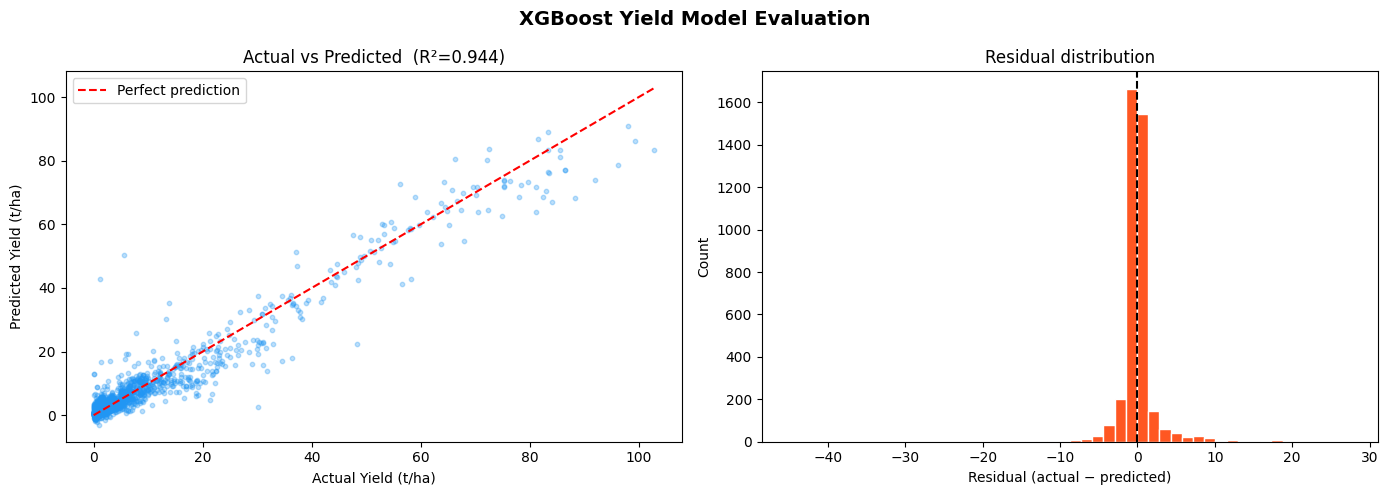

In [27]:
# ── Evaluation ────────────────────────────────────────────────────────────────
y_pred = yield_model.predict(X_test)

r2   = r2_score(y_test, y_pred)
mae  = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print('──── Yield Model Performance ────')
print(f'R² Score : {r2:.4f}   (1.0 = perfect)')
print(f'MAE      : {mae:.4f}  t/ha average error')
print(f'RMSE     : {rmse:.4f} t/ha')

# Actual vs predicted scatter
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_test, y_pred, alpha=0.3, s=10, color='#2196F3')
lim = max(y_test.max(), y_pred.max())
ax1.plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect prediction')
ax1.set_xlabel('Actual Yield (t/ha)')
ax1.set_ylabel('Predicted Yield (t/ha)')
ax1.set_title(f'Actual vs Predicted  (R²={r2:.3f})', fontsize=12)
ax1.legend()

residuals = y_test - y_pred
ax2.hist(residuals, bins=50, color='#FF5722', edgecolor='white')
ax2.axvline(0, color='black', lw=1.5, linestyle='--')
ax2.set_xlabel('Residual (actual − predicted)')
ax2.set_ylabel('Count')
ax2.set_title('Residual distribution', fontsize=12)

plt.suptitle('XGBoost Yield Model Evaluation', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

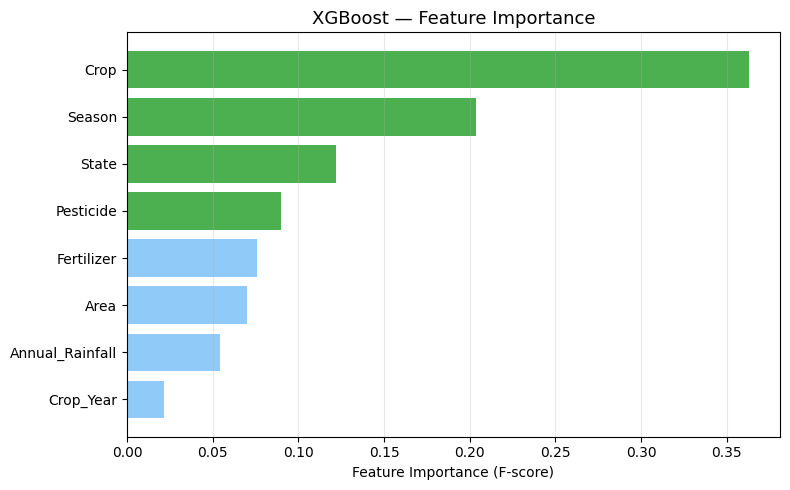

In [28]:
# ── Feature importance plot ───────────────────────────────────────────────────
importances = yield_model.feature_importances_
feat_df = pd.DataFrame({'feature': FEATURES, 'importance': importances})
feat_df = feat_df.sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#4CAF50' if v > feat_df['importance'].median()
          else '#90CAF9' for v in feat_df['importance']]
ax.barh(feat_df['feature'], feat_df['importance'], color=colors)
ax.set_xlabel('Feature Importance (F-score)')
ax.set_title('XGBoost — Feature Importance', fontsize=13)
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

---
## Part 12 — Save Yield Model

In [29]:
# ── Save yield model + encoders + scaler ─────────────────────────────────────
SAVE_DIR = Path('/kaggle/working') if IN_KAGGLE else Path('.')
YIELD_PATH = SAVE_DIR / 'yield_model.pkl'

yield_bundle = {
    'model':    yield_model,
    'scaler':   scaler,
    'encoders': encoders,
    'features': FEATURES,
    'r2_score': r2,
}

with open(YIELD_PATH, 'wb') as f:
    pickle.dump(yield_bundle, f)

print(f'✓ Saved: {YIELD_PATH}')
print(f'  R² = {r2:.4f}')

if IN_COLAB:
    from google.colab import files
    files.download(str(YIELD_PATH))
    print('Download started — save to your Project/models/ folder.')
elif IN_KAGGLE:
    print('Find the file in the Output panel → Save Version → download yield_model.pkl')


✓ Saved: /kaggle/working/yield_model.pkl
  R² = 0.9437
Find the file in the Output panel → Save Version → download yield_model.pkl


In [30]:
# ── predict_yield() — reusable inference function ─────────────────────────────
def predict_yield(crop: str, crop_year: int, season: str, state: str,
                  area: float, annual_rainfall: float,
                  fertilizer: float, pesticide: float) -> dict:
    """
    Predict crop yield from farm input features.

    Returns:
        dict with predicted yield and confidence range.
    """
    try:
        crop_enc    = encoders['Crop'].transform([crop.strip()])[0]
        season_enc  = encoders['Season'].transform([season.strip()])[0]
        state_enc   = encoders['State'].transform([state.strip()])[0]
    except ValueError as e:
        return {'error': f'Unknown value: {e}'}

    row = np.array([[crop_enc, crop_year, season_enc, state_enc,
                     area, annual_rainfall, fertilizer, pesticide]])
    row_scaled   = scaler.transform(row)
    predicted    = float(yield_model.predict(row_scaled)[0])
    margin       = predicted * 0.12   # ±12% confidence range

    return {
        'predicted_yield':  round(predicted, 3),
        'unit':             'tonnes/hectare',
        'confidence_range': {
            'low':  round(max(0, predicted - margin), 3),
            'high': round(predicted + margin, 3)
        }
    }


# ── Quick test ────────────────────────────────────────────────────────────────
result = predict_yield(
    crop='Rice', crop_year=2020, season='Kharif',
    state='Punjab', area=5000.0,
    annual_rainfall=650.0, fertilizer=200000.0, pesticide=500.0
)
print('--- Yield Prediction Result ---')
for k, v in result.items():
    print(f'  {k}: {v}')

--- Yield Prediction Result ---
  predicted_yield: 4.152
  unit: tonnes/hectare
  confidence_range: {'low': 3.653, 'high': 4.65}


---
## Summary

| Component | Model | Output |
|---|---|---|
| Disease Detection | ResNet50 (Transfer Learning) | Disease name + confidence + remedy |
| Yield Prediction | XGBoost Regressor | Yield in t/ha + confidence range |

### Output files (in `/kaggle/working/` or current directory)
- `disease_model.pt` → weights + class names → place in `Project/models/`
- `yield_model.pkl`  → model + scaler + encoders → place in `Project/models/`

### Download outputs on Kaggle
1. Click **Save Version** (top right) → Save
2. Open the saved version → **Output** tab → Download files

### Next step
Load both models in **FastAPI** (`Project/backend/main.py`) to serve predictions via REST API.
